# Code for extracting the phenological stage data and finding the mean breeding pairs based on the 'male huddle' phase 




# Manual phenological markers 

I have chosen to manually define what phenological stage I think the colonies are in in each image 

I use the size, shape, date and appearance of the huddles to determine which phase the colonies are in. 

As I am unable to exactly determine the differences between arrival, courtship, and mating, I have chosen to instead simply the definitions, as: 
- Females present (incorporates arrival, courtship, mating and egg hand over) 
- Male huddle (when only males are likely present)
- Female return (after the return of females, colonies become more dispersed and often difficult to quantify thus many of these obs are NA)


Using these values, I plan to estimate the breeding population of each colony by taking the mean and median, and error, of the count estimates taken during the 'male huddle' phase. 


I have also done this on Michelles 2024 data 

We will rerun the analysis on these datasets and calculate breeding pairs, and then compare to the chick counts as our model validation step. 




In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
from scipy import stats
from scipy.optimize import minimize
from sklearn.utils import resample

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10
})

print('Imports successful')

Imports successful


In [3]:
INPUTPATH = "/mnt/c/Users/rfo37/OneDrive - University of Canterbury/PostDoc/Population modelling/"

#dfRFD_v3 = pd.read_excel(
#    os.path.join(INPUTPATH, "dfRFD_with_predictions_cleaned_final.xlsx")) #cleaned and added phenology markers
#).drop(columns="Unnamed: 0")

dfRFD = pd.read_csv(os.path.join(INPUTPATH, "Final results/Actual final results/dfRFD_with_predictions_final_July2026.csv"))


In [18]:
print(dfRFD.columns.tolist())
print(dfRFD["phenology_est"].unique())

['colony_name', 'site_id', 'group', 'image_id', 'date', 'month', 'day', 'year', 'DOY', 'lat', 'lon', 'avg_size', 'area_m2', 'phenology_est', 'removed', 'observation(1-5)', 'grazing', 'incidence', 'azimuth', 'resolution', 'looks', 'orbit_state', 'polarization', 'slant_range', 'surface_type', 'obs', 'date_time', 'time', 'time_UTC', 'date_UTC', 'ts', 'met_ff10', 'temp_airK', 'met_humc', 'met_rad', 'd2m', 'rh_water', 'rh_ice', 'rho_pred', 'count_pred', 'rho_lower', 'rho_upper', 'count_lower', 'count_upper', 'Ta_C']
<ArrowStringArray>
['females present', 'male huddle', 'female return', nan]
Length: 4, dtype: str


In [19]:
#Ok and now we want to take those new data and extract the 'male huddle' data 
# Filter to male huddle phenology only
dfHuddle = dfRFD[dfRFD["phenology_est"] == "male huddle"].copy()


In [20]:

# Summary statistics per colony
summary = dfHuddle.groupby("colony_name").agg(
    lat        = ("lat", "first"),
    lon        = ("lon", "first"),
    n_obs      = ("count_pred", "count"),
    count_mean = ("count_pred", "mean"),
    count_med  = ("count_pred", "median"),
    lower_mean = ("count_lower", "mean"),
    lower_med  = ("count_lower", "median"),
    upper_mean = ("count_upper", "mean"),
    upper_med  = ("count_upper", "median"),
).reset_index()

# How different are upper and lower from the central estimate
summary["mean_range"]   = summary["upper_mean"] - summary["lower_mean"]
summary["mean_range_pct"] = (summary["mean_range"] / summary["count_mean"] * 100).round(1)
summary["uncertainty_pm"] = (summary["mean_range"] / 2).round(0)

print("Male huddle period — count predictions by colony:")
print(summary[["colony_name", "n_obs", "count_mean", "count_med",
               "lower_mean", "upper_mean", "mean_range_pct", "uncertainty_pm"]].round(0).to_string())

# New clean dataframe with date/doy included
dfHuddle_export = dfHuddle.groupby("colony_name").agg(
    lat          = ("lat", "first"),
    lon          = ("lon", "first"),
    date_first   = ("date", "min"),
    date_last    = ("date", "max"),
    DOY_mean     = ("DOY", "mean"),
    n_obs        = ("count_pred", "count"),
    count_mean   = ("count_pred", "mean"),
    count_median = ("count_pred", "median"),
    count_lower  = ("count_lower", "mean"),
    count_upper  = ("count_upper", "mean"),
).reset_index()


dfHuddle_export = dfHuddle_export.merge(
    summary[["colony_name", "uncertainty_pm", "mean_range_pct"]],
    on="colony_name",
    how="left"
)

print(f"\nExport dataframe: {len(dfHuddle_export)} colonies")
print(dfHuddle_export.head())


Male huddle period — count predictions by colony:
       colony_name  n_obs  count_mean  count_med  lower_mean  upper_mean  mean_range_pct  uncertainty_pm
0           Amanda      2      9282.0     9282.0      8229.0     10348.0            23.0          1059.0
1         Amundsen      2       291.0      291.0       262.0       322.0            21.0            30.0
2           Astrid      2      6253.0     6253.0      5632.0      6888.0            20.0           628.0
3             Atka      1     13926.0    13926.0     12437.0     15352.0            21.0          1457.0
4           Auster      2      6009.0     6009.0      5394.0      6629.0            21.0           618.0
5             Bear      2      4693.0     4693.0      4190.0      5202.0            22.0           506.0
6         Beaufort      1       564.0      564.0       497.0       632.0            24.0            67.0
7           Bowman      1      5188.0     5188.0      4740.0      5567.0            16.0           413.0
8    

In [21]:
print(dfHuddle_export.columns.tolist())
print(dfHuddle_export[["colony_name", "lat", "lon", "count_mean", "count_median", "uncertainty_pm"]].head(10).round(0))
print(f"\nTotal colonies: {len(dfHuddle_export)}")
print(f"Lat range: {dfHuddle_export['lat'].min():.1f} to {dfHuddle_export['lat'].max():.1f}")
print(f"Lon range: {dfHuddle_export['lon'].min():.1f} to {dfHuddle_export['lon'].max():.1f}")

['colony_name', 'lat', 'lon', 'date_first', 'date_last', 'DOY_mean', 'n_obs', 'count_mean', 'count_median', 'count_lower', 'count_upper', 'uncertainty_pm', 'mean_range_pct']
  colony_name   lat    lon  count_mean  count_median  uncertainty_pm
0      Amanda -69.0   77.0      9282.0        9282.0          1059.0
1    Amundsen -67.0   51.0       291.0         291.0            30.0
2      Astrid -70.0    8.0      6253.0        6253.0           628.0
3        Atka -71.0   -8.0     13926.0       13926.0          1457.0
4      Auster -67.0   64.0      6009.0        6009.0           618.0
5        Bear -74.0 -110.0      4693.0        4693.0           506.0
6    Beaufort -77.0  167.0       564.0         564.0            67.0
7      Bowman -65.0  103.0      5188.0        5188.0           413.0
8    Brownson -74.0 -104.0      4896.0        4896.0           526.0
9       Casey -67.0   47.0      1567.0        1567.0           176.0

Total colonies: 55
Lat range: -77.4 to -64.5
Lon range: -157.6 to 

# Propagating uncertainty in our breeding pair estimates: 

We have two sources of uncertainty, one being the standard errors reported for the density coefficents, and another being the standard deviation around the mean of the male huddle phase, created when we have multiple images of the 'male huddle'. 

These two types of error mean we need to combine them in a quadrature to accurately extrapolate the error across the different sources. 




In [22]:
# All colonies in dfRFD
all_colonies = set(dfRFD["colony_name"].unique())

# Colonies that have at least one male huddle observation
huddle_colonies = set(dfRFD[dfRFD["phenology_est"] == "male huddle"]["colony_name"].unique())

# Colonies that have observations but NO male huddle
no_huddle_colonies = all_colonies - huddle_colonies

print(f"Total colonies in dfRFD:        {len(all_colonies)}")
print(f"Colonies with male huddle obs:     {len(huddle_colonies)}")
print(f"Colonies WITHOUT male huddle obs:  {len(no_huddle_colonies)}")
print(f"\nColonies excluded (no male huddle):")
for c in sorted(no_huddle_colonies):
    phases = dfRFD[dfRFD["colony_name"] == c]["phenology_est"].value_counts()
    print(f"  {c:<25} — phases observed: {phases.to_dict()}")

Total colonies in dfRFD:        58
Colonies with male huddle obs:     55
Colonies WITHOUT male huddle obs:  3

Colonies excluded (no male huddle):
  Ragnhild                  — phases observed: {}
  Rothschild                — phases observed: {}
  Verlerger                 — phases observed: {'female return': 1}


In [23]:
# ── Rebuild dfHuddle_export with combined uncertainty ──────────────────────
dfHuddle_export = (dfHuddle
    .groupby("colony_name")
    .apply(lambda g: pd.Series({
        # Location
        "lat":              g["lat"].iloc[0],
        "lon":              g["lon"].iloc[0],

        # Temporal coverage
        "date_first":       g["ts"].min(),
        "date_last":        g["ts"].max(),
        "DOY_mean":         g["DOY"].mean(),

        # Sample size
        "n_obs":            len(g),

        # Central estimates
        "count_mean":       g["count_pred"].mean(),
        "count_median":     g["count_pred"].median(),

        # Source 1 — coefficient uncertainty (SE from weather density model)
        "coeff_lower":      g["count_lower"].mean(),
        "coeff_upper":      g["count_upper"].mean(),
        "coeff_se_pm":      (g["count_upper"] - g["count_lower"]).mean() / 2,

        # Source 2 — observation variance (SE of mean across images)
        "obs_std":          g["count_pred"].std()  if len(g) > 1 else np.nan,
        "obs_sem":          g["count_pred"].sem()  if len(g) > 1 else np.nan,
        "obs_lower":        g["count_pred"].mean() - g["count_pred"].sem() if len(g) > 1 else np.nan,
        "obs_upper":        g["count_pred"].mean() + g["count_pred"].sem() if len(g) > 1 else np.nan,

        # Combined uncertainty — added in quadrature
        "combined_se_pm":   (
            np.sqrt(
                ((g["count_upper"] - g["count_lower"]).mean() / 2) ** 2 +
                g["count_pred"].sem() ** 2
            ) if len(g) > 1
            else (g["count_upper"] - g["count_lower"]).mean() / 2
        ),

        # Confidence flag
        "uncertainty_flag": (
            "single obs"     if len(g) == 1
            else "low n"     if len(g) == 2
            else "good"      if len(g) >= 3
            else "unknown"
        ),
    }))
    .reset_index()
)

# ── Derived combined bounds ────────────────────────────────────────────────
dfHuddle_export["combined_lower"] = (
    dfHuddle_export["count_mean"] - dfHuddle_export["combined_se_pm"]
)
dfHuddle_export["combined_upper"] = (
    dfHuddle_export["count_mean"] + dfHuddle_export["combined_se_pm"]
)

# ── Legacy columns for backward compatibility ──────────────────────────────
dfHuddle_export["count_lower"]    = dfHuddle_export["coeff_lower"]
dfHuddle_export["count_upper"]    = dfHuddle_export["coeff_upper"]
dfHuddle_export["uncertainty_pm"] = dfHuddle_export["combined_se_pm"]
dfHuddle_export["mean_range_pct"] = (
    dfHuddle_export["combined_se_pm"] * 2 /
    dfHuddle_export["count_mean"] * 100
).round(1)

# ── Summary ────────────────────────────────────────────────────────────────
print(f"dfHuddle_export rebuilt: {len(dfHuddle_export)} colonies")
print(f"\nUncertainty flag summary:")
print(dfHuddle_export["uncertainty_flag"].value_counts().to_string())

print(f"\nUncertainty comparison (mean across colonies):")
print(f"  Coefficient SE ±:   {dfHuddle_export['coeff_se_pm'].mean():,.0f}")
print(f"  Observation SEM ±:  {dfHuddle_export['obs_sem'].mean():,.0f}")
print(f"  Combined SE ±:      {dfHuddle_export['combined_se_pm'].mean():,.0f}")

print(f"\nColony detail:")
print(dfHuddle_export[[
    "colony_name", "n_obs", "count_mean",
    "coeff_se_pm", "obs_sem",
    "combined_se_pm", "uncertainty_flag"
]].sort_values("count_mean", ascending=False).round(0).to_string(index=False))

# ── Export as clean numeric CSV ────────────────────────────────────────────
# Select and order columns explicitly
export_cols = [
    # Identity
    "colony_name", "lat", "lon",
    # Temporal
    "date_first", "date_last", "DOY_mean",
    # Sample size
    "n_obs", "uncertainty_flag",
    # Central estimates
    "count_mean", "count_median",
    # Source 1 — weather coefficient SE
    "coeff_lower", "coeff_upper", "coeff_se_pm",
    # Source 2 — observation variance SE
    "obs_std", "obs_sem", "obs_lower", "obs_upper",
    # Combined
    "combined_lower", "combined_upper", "combined_se_pm",
    # Summary
    "mean_range_pct",
]

dfExport = dfHuddle_export[export_cols].copy()

# Force all numeric columns to float
numeric_cols = [c for c in export_cols
                if c not in ["colony_name", "date_first",
                              "date_last", "uncertainty_flag"]]
for col in numeric_cols:
    dfExport[col] = pd.to_numeric(dfExport[col], errors="coerce")

# Format dates as strings for clean CSV output
dfExport["date_first"] = pd.to_datetime(dfExport["date_first"]).dt.strftime("%Y-%m-%d")
dfExport["date_last"]  = pd.to_datetime(dfExport["date_last"]).dt.strftime("%Y-%m-%d")

dfExport.to_csv(
    os.path.join(INPUTPATH, "Final results/Actual final results/dfHuddle_export_combined_uncertainty_July2026.csv"),
    index=False,
    float_format="%.2f"
)

print(f"\nExported {len(dfExport)} colonies × {len(export_cols)} columns")
print(f"Columns: {export_cols}")

dfHuddle_export rebuilt: 55 colonies

Uncertainty flag summary:
uncertainty_flag
low n         33
single obs    12
good          10

Uncertainty comparison (mean across colonies):
  Coefficient SE ±:   573
  Observation SEM ±:  561
  Combined SE ±:      795

Colony detail:
   colony_name  n_obs  count_mean  coeff_se_pm  obs_sem  combined_se_pm uncertainty_flag
       Colbeck      5     21418.0       2285.0   1803.0          2911.0             good
        Dawson      1     19422.0       2068.0      NaN          2068.0       single obs
       Coulman      4     16088.0       1882.0   1679.0          2521.0             good
      Drescher      2     14192.0       1494.0   1306.0          1984.0            low n
          Atka      1     13926.0       1457.0      NaN          1457.0       single obs
    Washington      3     11368.0       1178.0   1386.0          1819.0             good
        Dibble      2     10986.0        905.0    123.0           913.0            low n
      Stancomb

In [24]:
# ── Total breeding population summary ─────────────────────────────────────

# Central estimate
total_count_mean   = dfHuddle_export["count_mean"].sum()

# Coefficient uncertainty — systematic (same model applied to all colonies)
# Must be summed directly, not in quadrature
total_coeff_se     = dfHuddle_export["coeff_se_pm"].sum()

# Observation variance — random (independent between colonies)
# Can be combined in quadrature
total_obs_se       = np.sqrt((dfHuddle_export["obs_sem"].fillna(0) ** 2).sum())

# Combined total uncertainty
# Systematic coeff SE summed directly, random obs SE in quadrature
# Then combined in quadrature since the two sources are independent of each other
total_combined_se  = np.sqrt(total_coeff_se ** 2 + total_obs_se ** 2)

# Bounds
total_lower_1se    = total_count_mean - total_combined_se
total_upper_1se    = total_count_mean + total_combined_se
total_lower_95     = total_count_mean - 1.96 * total_combined_se
total_upper_95     = total_count_mean + 1.96 * total_combined_se

# Colony confidence flags
n_good   = (dfHuddle_export["uncertainty_flag"] == "good").sum()
n_low_n  = (dfHuddle_export["uncertainty_flag"] == "low n").sum()
n_single = (dfHuddle_export["uncertainty_flag"] == "single obs").sum()

print("=" * 65)
print("TOTAL BREEDING POPULATION ESTIMATE")
print("Emperor penguin male huddle period — 2025")
print("=" * 65)
print(f"  Colonies included:              {len(dfHuddle_export)}")
print(f"    Good confidence (n≥3):        {n_good}")
print(f"    Low n (n=2):                  {n_low_n}")
print(f"    Single obs (n=1):             {n_single}")
print()
print(f"  Total count (mean):             {total_count_mean:>12,.0f} individuals")
print()
print(f"  Uncertainty breakdown:")
print(f"    Coefficient SE (systematic):  {total_coeff_se:>12,.0f}")
print(f"    Observation SE (random):      {total_obs_se:>12,.0f}")
print(f"    Combined SE:                  {total_combined_se:>12,.0f}")
print()
print(f"  Note: coefficient uncertainty is treated as systematic")
print(f"  (same model coefficients applied to all colonies) and")
print(f"  summed directly. Observation variance is treated as")
print(f"  random (independent between colonies) and combined")
print(f"  in quadrature. The two sources are then combined")
print(f"  in quadrature to give the total combined SE.")
print()
print(f"  ±1 SE range (~68% coverage):")
print(f"    Lower:  {total_lower_1se:>12,.0f} individuals")
print(f"    Upper:  {total_upper_1se:>12,.0f} individuals")
print()
print(f"  ±1.96 SE range (~95% approx, assumes normality):")
print(f"    Lower:  {total_lower_95:>12,.0f} individuals")
print(f"    Upper:  {total_upper_95:>12,.0f} individuals")
print()
print(f"  Combined SE as % of total:      "
      f"{total_combined_se / total_count_mean * 100:.1f}%")
print()
print(f"  Reported as:")
print(f"  {total_count_mean:,.0f} ± {total_combined_se:,.0f} breeding pairs")
print(f"  (95% approx: {total_lower_95:,.0f} – {total_upper_95:,.0f})")
print("=" * 65)
print()
print("Per-colony breakdown:")
print(f"{'Colony':<22} {'n':>3} {'count_mean':>12} "
      f"{'coeff_se':>10} {'obs_sem':>10} {'combined_se':>12} {'flag'}")
print("-" * 82)
for _, r in dfHuddle_export.sort_values("count_mean",
                                         ascending=False).iterrows():
    obs_sem_str = (f"{r['obs_sem']:>10,.0f}"
                   if pd.notna(r["obs_sem"]) else "       n/a")
    print(f"{r['colony_name']:<22} {int(r['n_obs']):>3} "
          f"{r['count_mean']:>12,.0f} "
          f"{r['coeff_se_pm']:>10,.0f} "
          f"{obs_sem_str} "
          f"{r['combined_se_pm']:>12,.0f}  "
          f"{r['uncertainty_flag']}")
print("-" * 82)
print(f"{'TOTAL':<22} {int(dfHuddle_export['n_obs'].sum()):>3} "
      f"{total_count_mean:>12,.0f} "
      f"{total_coeff_se:>10,.0f} "
      f"{total_obs_se:>10,.0f} "
      f"{total_combined_se:>12,.0f}")
print("=" * 65)

# ── Export summary to CSV ──────────────────────────────────────────────────
summary_export = pd.DataFrame([{
    "description":              "Total breeding population estimate",
    "season":                   "2025",
    "n_colonies":               len(dfHuddle_export),
    "n_good":                   n_good,
    "n_low_n":                  n_low_n,
    "n_single":                 n_single,
    "total_count_mean":         round(total_count_mean, 0),
    "coeff_se_systematic":      round(total_coeff_se, 0),
    "obs_se_random":            round(total_obs_se, 0),
    "combined_se":              round(total_combined_se, 0),
    "combined_se_pct":          round(total_combined_se / total_count_mean * 100, 1),
    "lower_1se":                round(total_lower_1se, 0),
    "upper_1se":                round(total_upper_1se, 0),
    "lower_95ci":               round(total_lower_95, 0),
    "upper_95ci":               round(total_upper_95, 0),
}])

summary_export.to_csv(
    os.path.join(INPUTPATH, "Final results/Actual final results/total_population_summary_July2026.csv"),
    index=False,
    float_format="%.0f"
)
print(f"\nSummary exported to total_population_summary.csv")

TOTAL BREEDING POPULATION ESTIMATE
Emperor penguin male huddle period — 2025
  Colonies included:              55
    Good confidence (n≥3):        10
    Low n (n=2):                  33
    Single obs (n=1):             12

  Total count (mean):                  301,195 individuals

  Uncertainty breakdown:
    Coefficient SE (systematic):        31,504
    Observation SE (random):             5,032
    Combined SE:                        31,904

  Note: coefficient uncertainty is treated as systematic
  (same model coefficients applied to all colonies) and
  summed directly. Observation variance is treated as
  random (independent between colonies) and combined
  in quadrature. The two sources are then combined
  in quadrature to give the total combined SE.

  ±1 SE range (~68% coverage):
    Lower:       269,292 individuals
    Upper:       333,099 individuals

  ±1.96 SE range (~95% approx, assumes normality):
    Lower:       238,664 individuals
    Upper:       363,727 individua

In [25]:
print("Most northerly colony (highest/least negative latitude):")
print(dfHuddle_export.loc[dfHuddle_export["lat"].idxmax(), 
                           ["colony_name", "lat", "lon"]])

print("\nMost southerly colony (lowest/most negative latitude):")
print(dfHuddle_export.loc[dfHuddle_export["lat"].idxmin(), 
                           ["colony_name", "lat", "lon"]])

#Gould Bay is further south but was not estimated breeding pairs. 


print("\nFull latitudinal range:")
print(dfHuddle_export[["colony_name", "lat", "lon"]]
      .sort_values("lat", ascending=False)
      .to_string(index=False))

Most northerly colony (highest/least negative latitude):
colony_name    Snow Hill
lat              -64.524
lon              -57.445
Name: 46, dtype: object

Most southerly colony (lowest/most negative latitude):
colony_name       Crozier
lat            -77.448746
lon            169.277041
Name: 12, dtype: object

Full latitudinal range:
   colony_name        lat         lon
     Snow Hill -64.524000  -57.445000
    Shackleton -64.952100   95.917600
        Bowman -65.281300  103.186400
     Pointsett -65.826400  113.301000
      Peterson -65.840500  110.143900
        Dibble -66.023400  134.739800
    Vanhoeffen -66.067452   86.496904
         Jason -66.100000  -60.669000
       Sabrina -66.108900  121.257000
    Posadowsky -66.131000   89.820000
      Porpoise -66.260860  129.981070
West Ice Shelf -66.261000   81.484000
       Karelin -66.408600   85.426600
       Haswell -66.539100   93.033000
          Kloa -66.641000   57.278000
      Geologie -66.674000  140.005000
        Ninnis 

# Mapping 

I will redo this in ArcGIS Pro, but is interesting to see a rough idea of the colony sizes here: 

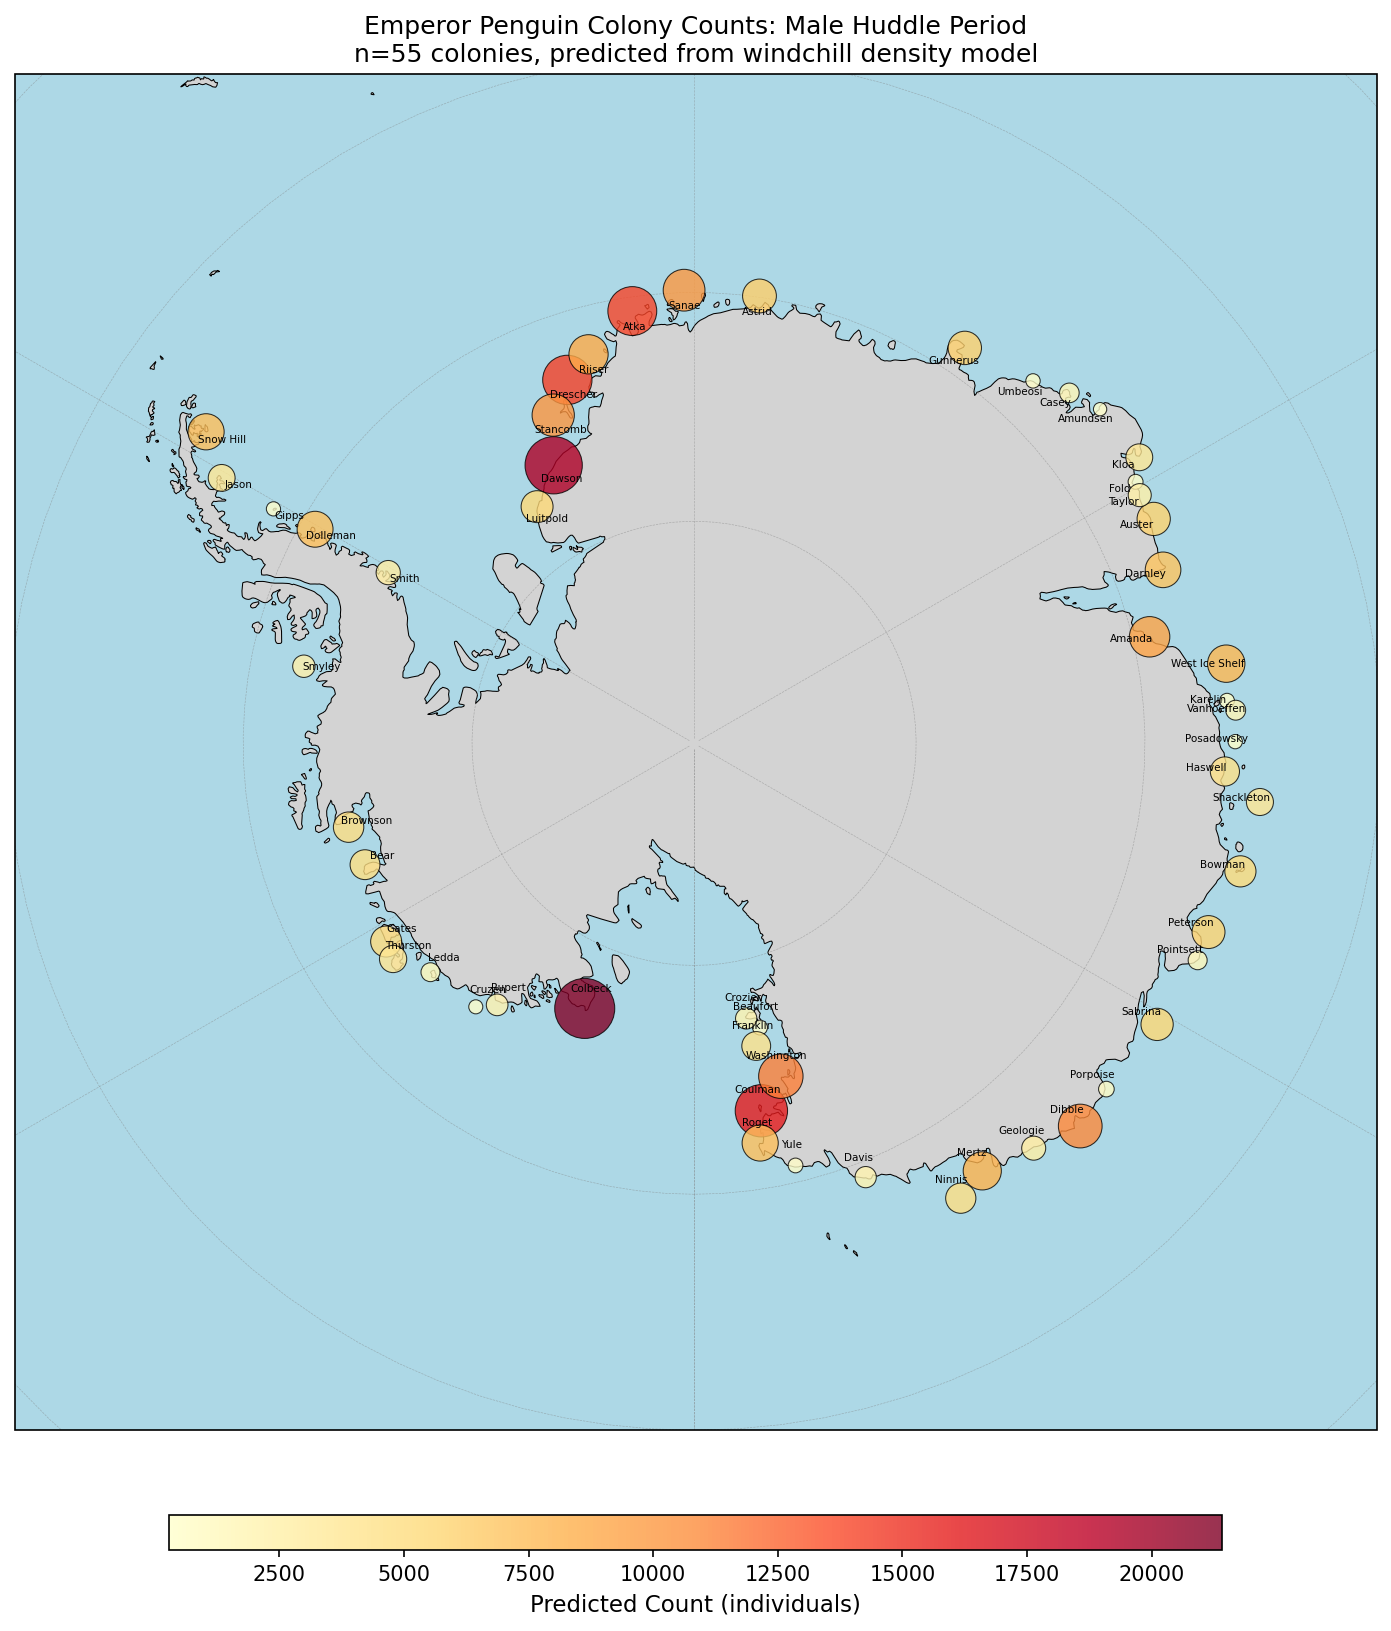


Largest colony:  Colbeck (21,418 individuals)
Smallest colony: Amundsen (291 individuals)
Total predicted: 301,195 individuals


In [26]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())

# Set map extent to Antarctica
ax.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND,       facecolor="lightgray",  zorder=1)
ax.add_feature(cfeature.OCEAN,      facecolor="lightblue",  zorder=0)
ax.add_feature(cfeature.COASTLINE,  linewidth=0.5,          zorder=2)
ax.add_feature(cfeature.BORDERS,    linewidth=0.3,          zorder=2)
ax.gridlines(linewidth=0.3, color="gray", alpha=0.5, linestyle="--")

# Scale marker size by count_mean
count_vals = dfHuddle_export["count_mean"].values
size_scaled = (count_vals / count_vals.max()) * 800 + 30

# Colour by count_mean
norm  = mcolors.Normalize(vmin=count_vals.min(), vmax=count_vals.max())
cmap  = plt.cm.YlOrRd

sc = ax.scatter(
    dfHuddle_export["lon"].values,
    dfHuddle_export["lat"].values,
    s=size_scaled,
    c=count_vals,
    cmap=cmap,
    norm=norm,
    alpha=0.8,
    edgecolors="black",
    linewidths=0.5,
    transform=ccrs.PlateCarree(),
    zorder=3
)

# Colorbar
cbar = plt.colorbar(sc, ax=ax, orientation="horizontal",
                    pad=0.05, shrink=0.6, aspect=30)
cbar.set_label("Predicted Count (individuals)", fontsize=11)

# Label colonies
for _, row in dfHuddle_export.iterrows():
    ax.text(
        row["lon"], row["lat"] - 0.8,
        row["colony_name"],
        fontsize=5,
        ha="center",
        transform=ccrs.PlateCarree(),
        zorder=4
    )

ax.set_title(
    f"Emperor Penguin Colony Counts: Male Huddle Period\n"
    f"n={len(dfHuddle_export)} colonies, predicted from windchill density model",
    fontsize=12
)

plt.tight_layout()
plt.savefig(os.path.join(INPUTPATH, "fig_antarctica_colony_counts.png"),
            dpi=200, bbox_inches="tight")
plt.show()

print(f"\nLargest colony:  {dfHuddle_export.loc[dfHuddle_export['count_mean'].idxmax(), 'colony_name']} "
      f"({dfHuddle_export['count_mean'].max():,.0f} individuals)")
print(f"Smallest colony: {dfHuddle_export.loc[dfHuddle_export['count_mean'].idxmin(), 'colony_name']} "
      f"({dfHuddle_export['count_mean'].min():,.0f} individuals)")
print(f"Total predicted: {dfHuddle_export['count_mean'].sum():,.0f} individuals")

In [27]:
import cartopy.io.shapereader as shpreader
shpreader.natural_earth(resolution='10m', category='physical', name='antarctic_ice_shelves_polys')

PosixPath('/home/rfo37/.local/share/cartopy/shapefiles/natural_earth/physical/ne_10m_antarctic_ice_shelves_polys.shp')

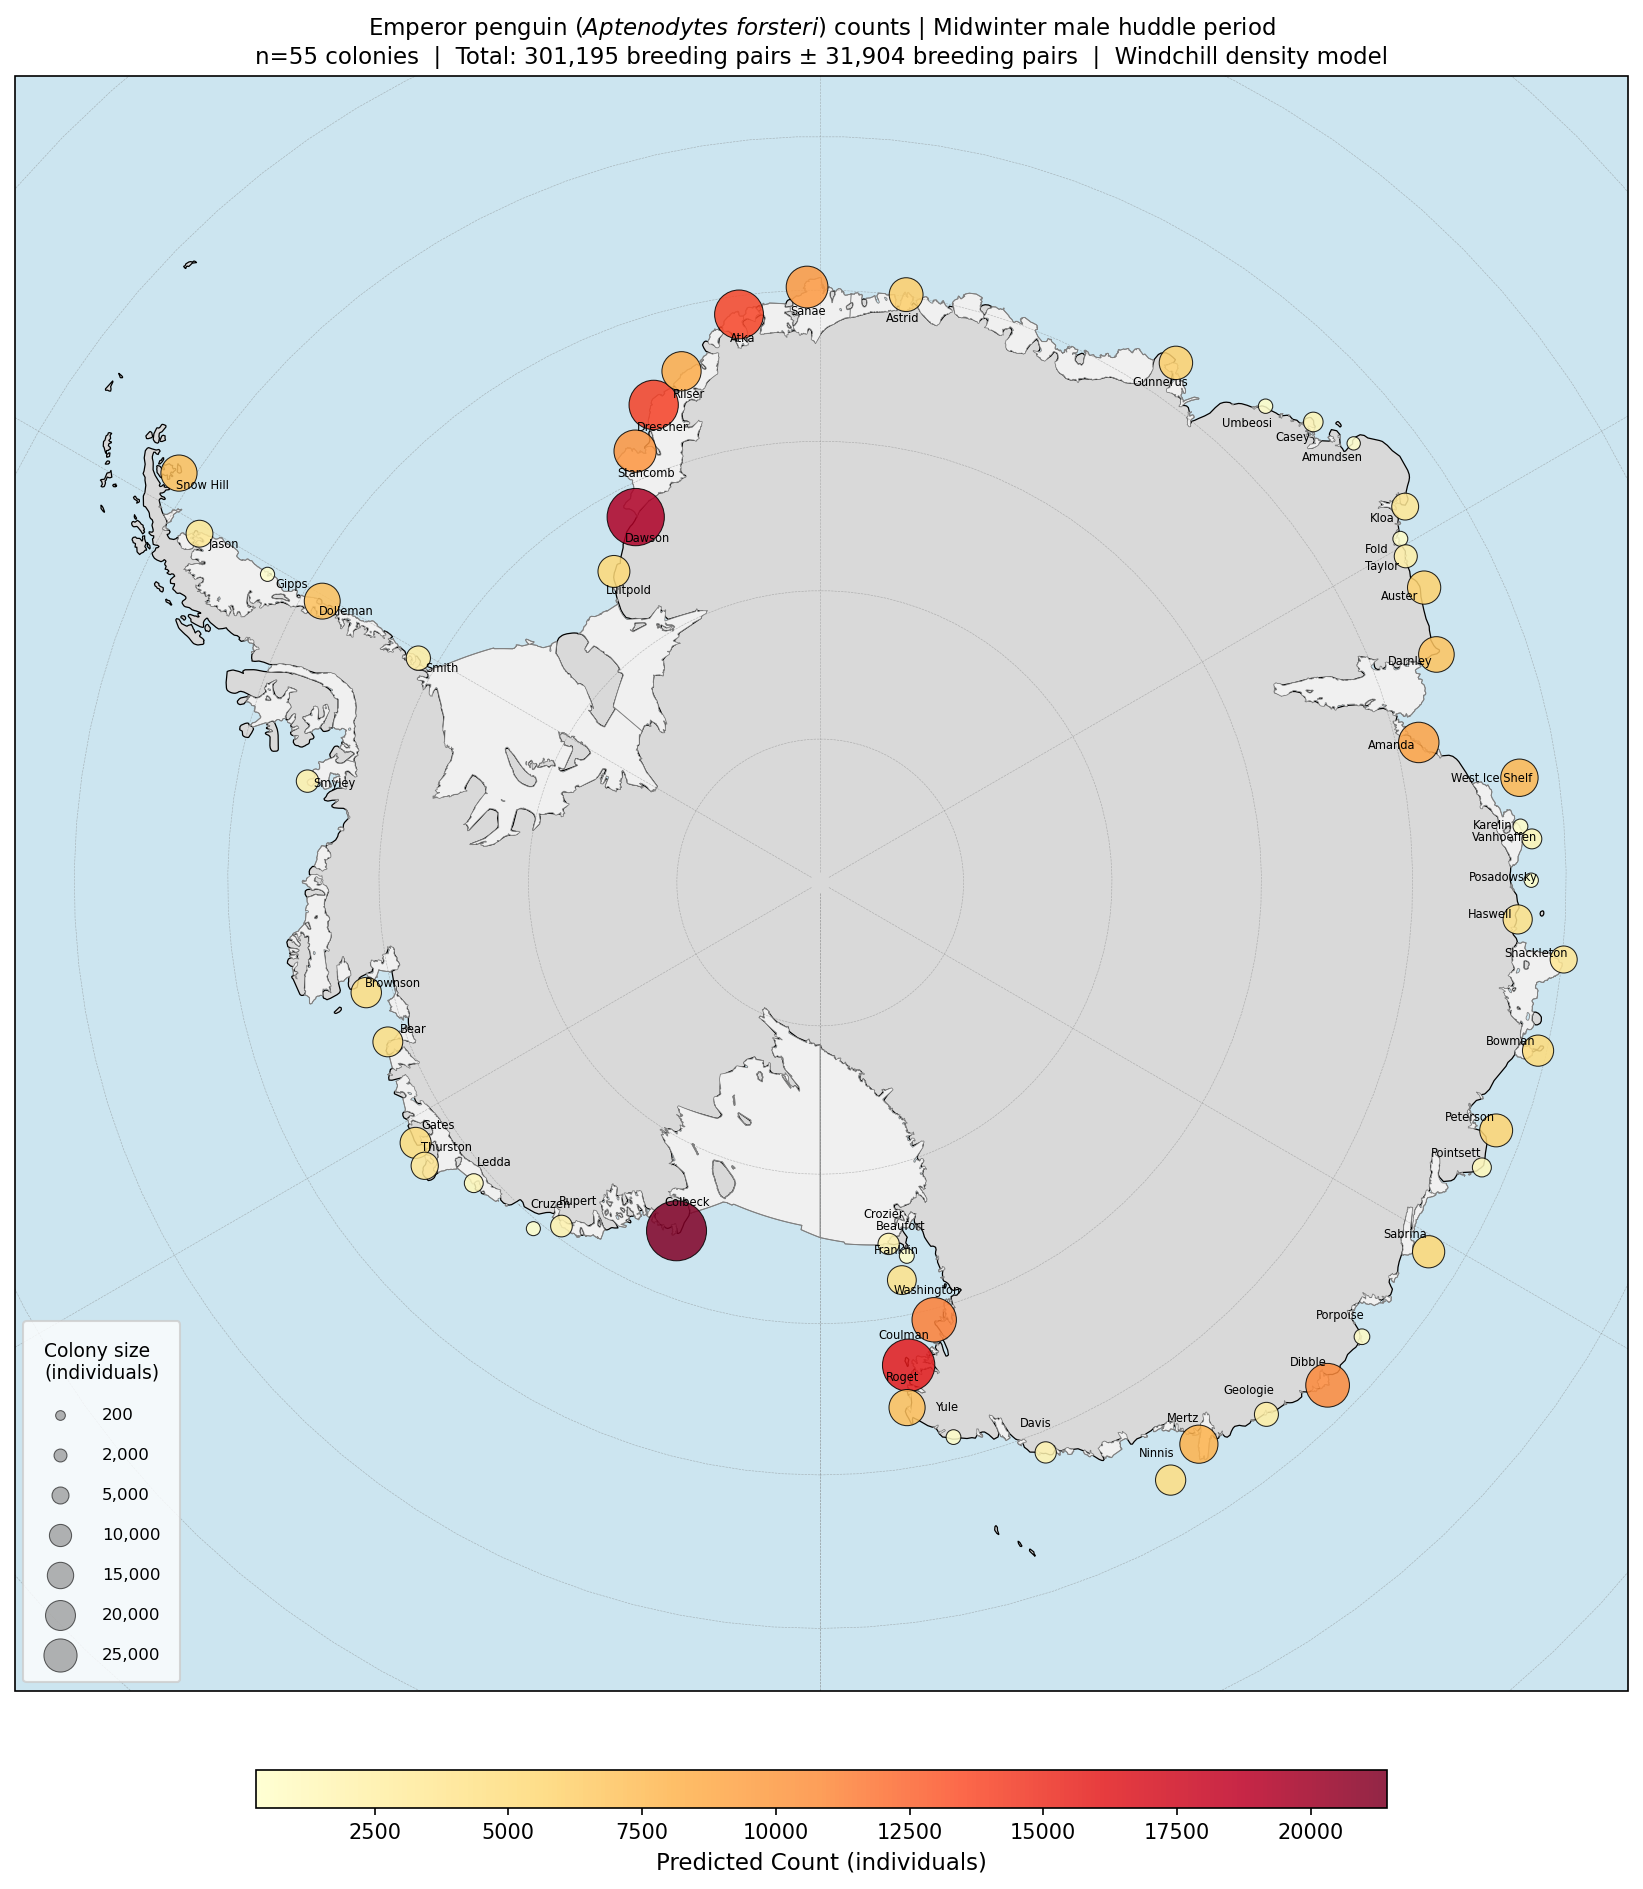

Largest:  Colbeck — 21,418 ± 2,911
Smallest: Amundsen — 291
Total:    301,195 individuals across 55 colonies


In [32]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np
from cartopy.feature import NaturalEarthFeature

fig = plt.figure(figsize=(14, 14))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -63], crs=ccrs.PlateCarree())

# Map features
ax.add_feature(cfeature.LAND,       facecolor="#d9d9d9", zorder=1)
ax.add_feature(cfeature.OCEAN,      facecolor="#cce5f0", zorder=0)
ax.add_feature(cfeature.COASTLINE,  linewidth=0.6,       zorder=2)

# Ice shelves from Natural Earth
ice_shelves = NaturalEarthFeature(
    category="physical",
    name="antarctic_ice_shelves_polys",
    scale="10m",
    facecolor="#f0f0f0",
    edgecolor="gray",
    linewidth=0.4
)
ax.add_feature(ice_shelves, zorder=2)

ice_shelf_lines = NaturalEarthFeature(
    category="physical",
    name="antarctic_ice_shelves_lines",
    scale="10m",
    facecolor="none",
    edgecolor="gray",
    linewidth=0.5
)
ax.add_feature(ice_shelf_lines, zorder=2)

gl = ax.gridlines(linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
# Scale and colour
count_vals  = dfHuddle_export["count_mean"].values
size_scaled = (count_vals / count_vals.max()) * 800 + 30
norm        = mcolors.Normalize(vmin=count_vals.min(), vmax=count_vals.max())
cmap        = plt.cm.YlOrRd

sc = ax.scatter(
    dfHuddle_export["lon"].values,
    dfHuddle_export["lat"].values,
    s=size_scaled,
    c=count_vals,
    cmap=cmap,
    norm=norm,
    alpha=0.85,
    edgecolors="black",
    linewidths=0.5,
    transform=ccrs.PlateCarree(),
    zorder=3
)
largest = dfHuddle_export.loc[dfHuddle_export["count_mean"].idxmax()]
# Colorbar
cbar = plt.colorbar(sc, ax=ax, orientation="horizontal",
                    pad=0.04, shrink=0.55, aspect=30)
cbar.set_label("Predicted Count (individuals)", fontsize=11)

# Size legend
legend_counts = [200, 2000, 5000, 10000, 15000, 20000, 25000]
legend_sizes  = [(c / count_vals.max()) * 200 + 20 for c in legend_counts]
legend_handles = [
    plt.scatter([], [], s=s, c="grey", alpha=0.6,
                edgecolors="black", linewidths=0.5,
                label=f"{int(c):,}")
    for s, c in zip(legend_sizes, legend_counts)
]




ax.legend(
    handles=legend_handles,
    title="Colony size\n(individuals)",
    loc="lower left",
    framealpha=0.8,
    fontsize=8,
    title_fontsize=9,
    labelspacing=1.5,     # vertical space between entries
    handletextpad=1.5,    # space between circle and label text
    borderpad=1.2,        # padding inside the legend box
    scatterpoints=1,
)

for _, row in dfHuddle_export.iterrows():
    ax.text(
        row["lon"], row["lat"] - 0.9,
        row["colony_name"],
        fontsize=5.5,
        ha="center",
        transform=ccrs.PlateCarree(),
        zorder=4
    )

ax.set_title(
    f"Emperor penguin ($\\it{{Aptenodytes\\ forsteri}}$) counts | Midwinter male huddle period\n"
    f"n={len(dfHuddle_export)} colonies  |  "
    f"Total: {summary_export['total_count_mean'].sum():,.0f} breeding pairs "
    f"\u00b1 {summary_export['combined_se'].sum():,.0f} breeding pairs  |  "
    f"Windchill density model",
    fontsize=11
)

plt.tight_layout()
plt.savefig(os.path.join(INPUTPATH, "fig_antarctica_colony_counts_v2.png"),
            dpi=200, bbox_inches="tight")
plt.show()

print(f"Largest:  {largest['colony_name']} — {largest['count_mean']:,.0f} ± {largest['uncertainty_pm']:,.0f}")
print(f"Smallest: {dfHuddle_export.loc[dfHuddle_export['count_mean'].idxmin(), 'colony_name']} — "
      f"{dfHuddle_export['count_mean'].min():,.0f}")
print(f"Total:    {dfHuddle_export['count_mean'].sum():,.0f} individuals across {len(dfHuddle_export)} colonies")

# Estimating breeding pairs from manual phenological markers for Michelle's 2024 data

In [4]:
dfMLR = pd.read_csv(os.path.join(INPUTPATH, "Final results/Actual final results/dfMLR_with_predictions_final_July2026.csv")) #This data includes the manual phenological marker, 'females present', 'male huddle', 'female return'. 


In [5]:
#Calculating the uncertainitys to correct the uncertainity assumption, incorportaing both the coefficient uncertainty and the SEM uncertainaty 
dfMLR["datetime"] = pd.to_datetime(dfMLR["datetime"], 
                                    format="mixed", 
                                    dayfirst=True)

#We want to take those new data and extract the 'male huddle' data 
# Filter to male huddle phenology only
dfHuddleMLR = dfMLR[dfMLR["phenology_est"] == "male huddle"].copy()

# Summary statistics per colony
summary = dfHuddleMLR.groupby("colony_name").agg(
    lat        = ("lat", "first"),
    lon        = ("lon", "first"),
    n_obs      = ("count_pred", "count"),
    count_mean = ("count_pred", "mean"),
    count_med  = ("count_pred", "median"),
    lower_mean = ("count_lower", "mean"),
    lower_med  = ("count_lower", "median"),
    upper_mean = ("count_upper", "mean"),
    upper_med  = ("count_upper", "median"),
).reset_index()



# ── Build dfHuddleMLR_export with combined uncertainty ───────────────────
dfHuddleMLR_export = (dfHuddleMLR
    .groupby("colony_name")
    .apply(lambda g: pd.Series({
        # Location
        "lat":              g["lat"].iloc[0],
        "lon":              g["lon"].iloc[0],

        # Temporal coverage
        "date_first":       g["datetime"].min(),
        "date_last":        g["datetime"].max(),
        "DOY_mean":         g["doy"].mean(),

        # Sample size
        "n_obs":            len(g),

        # Central estimates
        "count_mean":       g["count_pred"].mean(),
        "count_median":     g["count_pred"].median(),

        # Source 1 — coefficient uncertainty (SE from weather density model)
        "coeff_lower":      g["count_lower"].mean(),
        "coeff_upper":      g["count_upper"].mean(),
        "coeff_se_pm":      (g["count_upper"] - g["count_lower"]).mean() / 2,

        # Source 2 — observation variance (SE of mean across images)
        "obs_std":          g["count_pred"].std()  if len(g) > 1 else np.nan,
        "obs_sem":          g["count_pred"].sem()  if len(g) > 1 else np.nan,
        "obs_lower":        g["count_pred"].mean() - g["count_pred"].sem()
                            if len(g) > 1 else np.nan,
        "obs_upper":        g["count_pred"].mean() + g["count_pred"].sem()
                            if len(g) > 1 else np.nan,

        # Combined uncertainty — added in quadrature
        "combined_se_pm":   (
            np.sqrt(
                ((g["count_upper"] - g["count_lower"]).mean() / 2) ** 2 +
                g["count_pred"].sem() ** 2
            ) if len(g) > 1
            else (g["count_upper"] - g["count_lower"]).mean() / 2
        ),

        # Confidence flag
        "uncertainty_flag": (
            "single obs" if len(g) == 1
            else "low n"  if len(g) == 2
            else "good"   if len(g) >= 3
            else "unknown"
        ),
    }))
    .reset_index()
)

# ── Derived combined bounds ────────────────────────────────────────────────
dfHuddleMLR_export["combined_lower"] = (
    dfHuddleMLR_export["count_mean"] - dfHuddleMLR_export["combined_se_pm"]
)
dfHuddleMLR_export["combined_upper"] = (
    dfHuddleMLR_export["count_mean"] + dfHuddleMLR_export["combined_se_pm"]
)

# ── Legacy columns for backward compatibility ──────────────────────────────
dfHuddleMLR_export["count_lower"]    = dfHuddleMLR_export["coeff_lower"]
dfHuddleMLR_export["count_upper"]    = dfHuddleMLR_export["coeff_upper"]
dfHuddleMLR_export["uncertainty_pm"] = dfHuddleMLR_export["combined_se_pm"]
dfHuddleMLR_export["mean_range_pct"] = (
    dfHuddleMLR_export["combined_se_pm"] * 2 /
    dfHuddleMLR_export["count_mean"] * 100
).round(1)

# ── Summary ────────────────────────────────────────────────────────────────
print(f"dfHuddleMLR_export rebuilt: {len(dfHuddleMLR_export)} colonies")
print(f"\nUncertainty flag summary:")
print(dfHuddleMLR_export["uncertainty_flag"].value_counts().to_string())

print(f"\nUncertainty comparison (mean across colonies):")
print(f"  Coefficient SE ±:   {dfHuddleMLR_export['coeff_se_pm'].mean():,.0f}")
print(f"  Observation SEM ±:  {dfHuddleMLR_export['obs_sem'].mean():,.0f}")
print(f"  Combined SE ±:      {dfHuddleMLR_export['combined_se_pm'].mean():,.0f}")

print(f"\nColony detail:")
print(dfHuddleMLR_export[[
    "colony_name", "n_obs", "count_mean",
    "coeff_se_pm", "obs_sem",
    "combined_se_pm", "uncertainty_flag"
]].sort_values("count_mean", ascending=False).round(0).to_string(index=False))

# ── Export as clean numeric CSV ────────────────────────────────────────────
export_cols = [
    "colony_name", "lat", "lon",
    "date_first", "date_last", "DOY_mean",
    "n_obs", "uncertainty_flag",
    "count_mean", "count_median",
    "coeff_lower", "coeff_upper", "coeff_se_pm",
    "obs_std", "obs_sem", "obs_lower", "obs_upper",
    "combined_lower", "combined_upper", "combined_se_pm",
    "mean_range_pct",
]

dfMLR_export_out = dfHuddleMLR_export[export_cols].copy()

numeric_cols = [c for c in export_cols
                if c not in ["colony_name", "date_first",
                              "date_last", "uncertainty_flag"]]
for col in numeric_cols:
    dfMLR_export_out[col] = pd.to_numeric(dfMLR_export_out[col], errors="coerce")

dfMLR_export_out["date_first"] = pd.to_datetime(
    dfMLR_export_out["date_first"], 
    format="mixed", 
    dayfirst=True
).dt.strftime("%Y-%m-%d")

dfMLR_export_out["date_last"] = pd.to_datetime(
    dfMLR_export_out["date_last"], 
    format="mixed", 
    dayfirst=True
).dt.strftime("%Y-%m-%d")


dfMLR_export_out.to_csv(
    os.path.join(INPUTPATH, "Final results/Actual final results/dfHuddleMLR_export_combined_uncertainty_July2026.csv"),
    index=False,
    float_format="%.2f"
)
print(f"\nExported {len(dfMLR_export_out)} colonies × {len(export_cols)} columns")
print(f"Saved to dfHuddleMLR_export_combined_uncertainty.csv")

dfHuddleMLR_export rebuilt: 6 colonies

Uncertainty flag summary:
uncertainty_flag
good          5
single obs    1

Uncertainty comparison (mean across colonies):
  Coefficient SE ±:   847
  Observation SEM ±:  898
  Combined SE ±:      1,175

Colony detail:
colony_name  n_obs  count_mean  coeff_se_pm  obs_sem  combined_se_pm uncertainty_flag
    Coulman      4     16376.0       1792.0   1582.0          2391.0             good
 Washington      4     10341.0       1066.0   1569.0          1897.0             good
       Atka      3      8157.0        892.0    502.0          1023.0             good
      Roget      4      5261.0        546.0    764.0           939.0             good
   Franklin      1      5030.0        582.0      NaN           582.0       single obs
    Crozier      3      1825.0        205.0     71.0           217.0             good

Exported 6 colonies × 21 columns
Saved to dfHuddleMLR_export_combined_uncertainty.csv


## These data are then used to compare against chick counts in chick_comparison_refined notebook

